**MultiClass neural network for handwritten digit recognition**

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear,sigmoid,relu
from tensorflow.keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from utils import reshape_dataset

**creating a softmax function**

In [6]:
def softmax_function(z):
    total_values = sum(np.exp(i) for i in z)
    n = len(z)
    a = np.zeros(n)
    for i in range(n):
        a[i] = np.exp(z[i]) / total_values
    return a    

In [7]:
z = np.array([1., 2., 3., 4.])
print(softmax_function(z))
print(tf.nn.softmax(z))

[0.0320586  0.08714432 0.23688282 0.64391426]
tf.Tensor([0.0320586  0.08714432 0.23688282 0.64391426], shape=(4,), dtype=float64)


**Importing the dataset and splitting into training and testing dataset**

In [46]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

(60000, 28, 28)

**Reshaping the dataset**

In [52]:
X_train = reshape_dataset(X_train)
y_train = reshape_dataset(y_train) 
X_test = reshape_dataset(X_test)
y_test = reshape_dataset(y_test) 

(10000, 784)

In [16]:
print(f'The shape of the training data is :{X_train.shape}')
print(f'The shape of the target data is :{y_test.shape}')

The shape of the training data is :(60000, 784)
The shape of the target data is :(10000, 1)


**Feature scaling**

In [17]:
X_train = X_train / 255
X_test = X_test / 255

**Visualizing the training datas with the target variable**

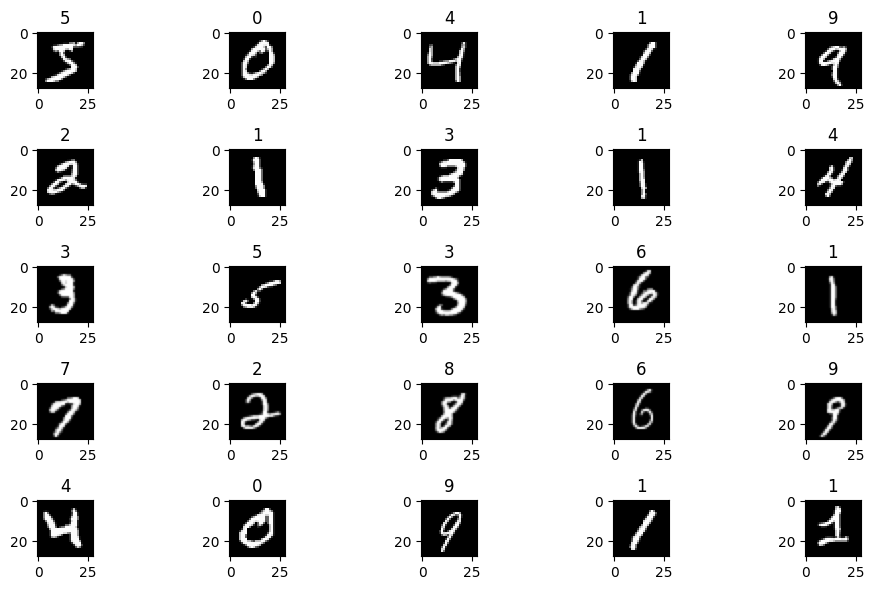

In [22]:
fig, axes = plt.subplots(5, 5, figsize=(10, 6)) 
for i,ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28,28),cmap='grey')
    ax.set_title(y_train[i][0])
plt.tight_layout()    
plt.show()    

**Creating a multiclass neural network model**

In [38]:
model = Sequential(
    [
        tf.keras.Input(shape=(784,)),
        Dense(128,activation='relu',name='layer1'),
        Dense(64,activation='relu',name='layer2'),
        Dense(10,activation='linear',name='layer3'),  #as we are going to use the softmax function while compiling the model for easier computation, so we are using linear activation here
        
    ]
)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                       │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer2 (Dense)                       │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer3 (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Extracting the layers and examining Weights shapes**

In [39]:
[layer1,layer2,layer3] = model.layers
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (784, 128), b1 shape = (128,)
W2 shape = (128, 64), b2 shape = (64,)
W3 shape = (64, 10), b3 shape = (10,)


In [40]:
model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)
history = model.fit(X_train,y_train,epochs=40)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.2378
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1001
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0704
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0557
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0437
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0364
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0298
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0255
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0212
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0195
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0173
Epoch 12/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0142
Epoch 13/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0151
Epoch 14/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0132
Epoch 15/40
1875/1875 ━━━━

**making the prediction by our model**

In [64]:
predictions = model.predict(X_test)
print(f'The output of the prediction by our model on first training example is: {np.argmax(predictions[0])}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
The output of the prediction by our model on first training example is: 7


In [65]:
print(f'The first target variable is: {y_test[0]}')

The first target variable is: [7]


**Plot of the predictions done by our model**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


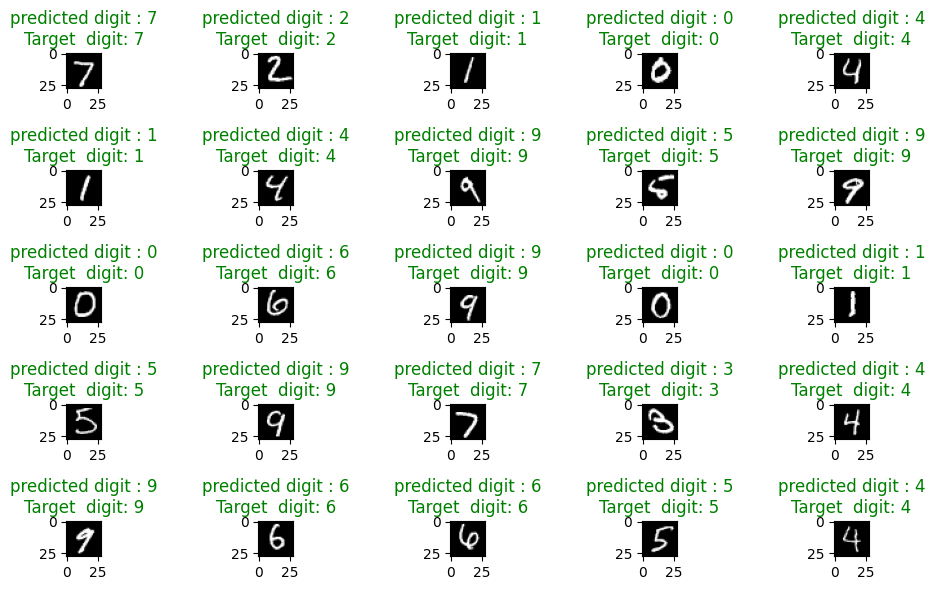

In [62]:
fig,axes = plt.subplots(5,5,figsize=(10,6))
for i,ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28),cmap='grey')
    prediction = model.predict(X_test[i].reshape(-1,784))
    predicted = np.argmax(prediction)  #this is the i indexed predicted digit , which obtained based on the index where the maximum probability is found
    target = y_test[i][0]  #this is the i indexed target digit
    color = 'green' if predicted == target else 'red'
    ax.set_title(f'predicted digit : {predicted}\nTarget  digit: {target}',c=color)
plt.tight_layout()
plt.show()
    
    